# Aplicacion en dataset Fashion MNIST

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from modelos import OneVsAll, OneVsOne, SoftMaxClassifier

In [2]:
df_train = pd.read_csv('./data/fashion-mnist_train.csv')
df_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

In [4]:
df_test = pd.read_csv('./data/fashion-mnist_test.csv')
df_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [5]:
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### One Vs All

In [7]:
OvA_model = OneVsAll()

In [8]:
OvA_model.fit(X_train, y_train)

,bin_clf,'logistic_reg'


In [9]:
y_pred_ova = OvA_model.predict(X_test)

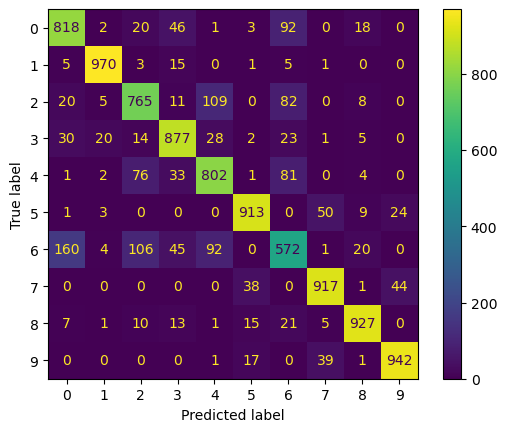

In [10]:
con_matrix_ova = confusion_matrix(y_true=y_test, y_pred=y_pred_ova)
matrix_dis_ova = ConfusionMatrixDisplay(confusion_matrix=con_matrix_ova)
matrix_dis_ova.plot()
plt.show()

In [11]:
print(classification_report(y_true=y_test, y_pred=y_pred_ova))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1000
           1       0.96      0.97      0.97      1000
           2       0.77      0.77      0.77      1000
           3       0.84      0.88      0.86      1000
           4       0.78      0.80      0.79      1000
           5       0.92      0.91      0.92      1000
           6       0.65      0.57      0.61      1000
           7       0.90      0.92      0.91      1000
           8       0.93      0.93      0.93      1000
           9       0.93      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### One Vs One

In [12]:
OvO_model = OneVsOne()

In [13]:
OvO_model.fit(X_train, y_train)

,bin_clf,'logistic_reg'


In [14]:
y_pred_ovo = OvO_model.predict(X_test)

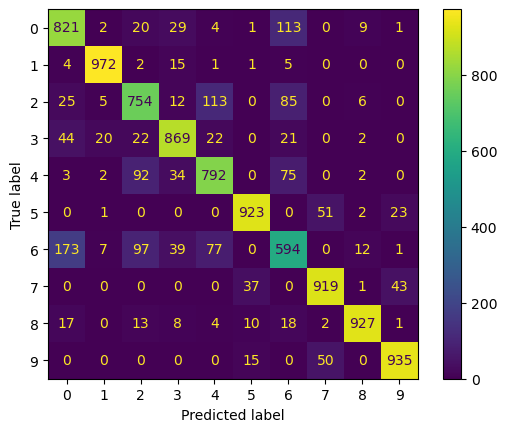

In [15]:
con_matrix_ovo = confusion_matrix(y_true=y_test, y_pred=y_pred_ovo)
matrix_dis_ovo = ConfusionMatrixDisplay(confusion_matrix=con_matrix_ovo)
matrix_dis_ovo.plot()
plt.show()

In [16]:
print(classification_report(y_true=y_test, y_pred=y_pred_ovo))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79      1000
           1       0.96      0.97      0.97      1000
           2       0.75      0.75      0.75      1000
           3       0.86      0.87      0.87      1000
           4       0.78      0.79      0.79      1000
           5       0.94      0.92      0.93      1000
           6       0.65      0.59      0.62      1000
           7       0.90      0.92      0.91      1000
           8       0.96      0.93      0.95      1000
           9       0.93      0.94      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### SoftMax Regression

In [17]:
softmax_model = SoftMaxClassifier()

In [18]:
softmax_model.fit(X_train, y_train)

,gradient_descent,'batch'
,epochs,100
,lr,0.01
,random_state,None
,batch_size,32


In [19]:
y_pred_softmax = softmax_model.predict(X_test)

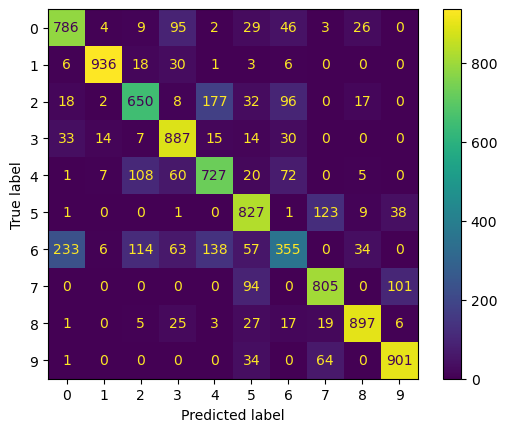

In [20]:
con_matrix_softmax = confusion_matrix(y_true=y_test, y_pred=y_pred_softmax)
matrix_dis_softmax = ConfusionMatrixDisplay(confusion_matrix=con_matrix_softmax)
matrix_dis_softmax.plot()
plt.show()

In [21]:
print(classification_report(y_true=y_test, y_pred=y_pred_softmax))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1000
           1       0.97      0.94      0.95      1000
           2       0.71      0.65      0.68      1000
           3       0.76      0.89      0.82      1000
           4       0.68      0.73      0.70      1000
           5       0.73      0.83      0.77      1000
           6       0.57      0.35      0.44      1000
           7       0.79      0.81      0.80      1000
           8       0.91      0.90      0.90      1000
           9       0.86      0.90      0.88      1000

    accuracy                           0.78     10000
   macro avg       0.77      0.78      0.77     10000
weighted avg       0.77      0.78      0.77     10000

